#**Analyse de la peur du chirurgien-dentiste au CHU-YO**

###**Contexte**
La peur du chirurgien-dentiste constitue un frein majeur au recours aux soins bucco-dentaires.
Cette étude vise à estimer sa prévalence et à identifier les facteurs associés chez les patients adultes consultant au CHU-YO.

###**Objectifs**
1. Estimer la prévalence de la peur du chirurgien-dentiste (score DAS de Corah ≥ 13).
2. Identifier les facteurs sociodémographiques, cliniques et comportementaux associés.
3. Décrire les préoccupations des patients présentant une anxiété sévère (score DAS ≥ 15).
4. Identifier les mesures suggérées par les patients pour réduire leur anxiété.

##**Importation et nettoyage des données**

###**Importation et nettoyage des données**

* **pandas (pd)** : sert à lire le fichier Excel, manipuler les colonnes, compter les modalités, créer des tableaux descriptifs;
* **numpy (np)** : utile ici pour np.inf, c’est-à-dire une borne supérieure infinie pour la dernière classe d’âge;
* **matplotlib.pyplot (plt)** : sert à construire les graphiques, ici le diagramme en camembert.

###

In [ ]:
# ============================================================
# CELLULE 1 : IMPORTATION DES PACKAGES
# ============================================================

import pandas as pd          # Manipulation et analyse des données tabulaires
import numpy as np           # Calcul numérique, gestion des bornes et valeurs spéciales
import matplotlib.pyplot as plt   # Visualisation graphique

###**Importation des données**
Cette cellule charge la base de données Excel dans un DataFrame appelé df.
Le DataFrame est la structure centrale de travail dans pandas.

In [ ]:
# ============================================================
# IMPORTATION DE LA BASE DE DONNÉES
# ============================================================

# Upload depuis votre ordinateur
from google.colab import files # Importe le module files de google.colab pour l'upload de fichiers
import io # Importe le module io pour gérer les flux d'entrée/sortie
uploaded = files.upload()   # Ouvre une boîte de dialogue pour sélectionner le fichier BASE_DORA_PROPRE.xlsx
filename = list(uploaded.keys())[0] # Récupère le nom du fichier uploadé

Saving BASE_DORA_PROPRE.xlsx to BASE_DORA_PROPRE (1).xlsx


###**Aperçu initial des données**
* head() : montre les premières observations ;
* tail() : montre les dernières ;
* shape : donne le nombre de lignes et de colonnes.

Cette étape permet de vérifier rapidement que le fichier a bien été importé.

In [ ]:
# ============================================================
# APERÇU INITIAL DES DONNÉES
# ============================================================
df = pd.read_excel("BASE_DORA_PROPRE.xlsx")

print("Aperçu des 5 premières lignes :")
display(df.head(3))

print("Dimensions de la base (lignes, colonnes) :")
print(df.shape)

Aperçu des 5 premières lignes :


,sexe,age,niveau_education,profession,premiere_visite_dentiste,connaissance_dentiste_avant_visite,experience_negative_dentiste,experience_negative_precision,motif_consultation,frequence_visite_dentiste,...,score_anxiete_1,score_anxiete_2,score_anxiete_3,score_anxiete_4,score_anxiete_total,pref_musique_douce,pref_decoration_apaisante,pref_masque_yeux,pref_explication_etapes_soin,pref_bouchons_oreilles
0,feminin,29,supérieur,sans emploi,oui,oui,non,NaN,motif esthétique,au besoin,...,4,3,3,3,13,oui,oui,non,oui,non
1,masculin,27,supérieur,sans emploi,oui,oui,non,NaN,consultation de contrôle,au besoin,...,4,4,3,3,14,non,oui,non,oui,oui
2,feminin,30,sans instruction formelle,commerçant,non,oui,non,NaN,douleur bucco-dentaire,au besoin,...,3,3,3,3,12,non,oui,oui,oui,non


Dimensions de la base (lignes, colonnes) :
(279, 32)


La base de données compte 279 lignes et 32 colonnes soit 32 variables

###**Types de variables et description générale**
* dtypes permet d’identifier la nature de chaque variable ;
* describe() résume les variables quantitatives ;
* describe(include="all") ajoute aussi les variables qualitatives.

C’est une étape essentielle pour repérer :

* les variables mal typées ;
* les modalités inhabituelles ;
* les valeurs manquantes éventuelles.

In [ ]:
## ============================================================
# STRUCTURE ET DESCRIPTION GÉNÉRALE
# ============================================================

print("Types des variables :")
display(df.dtypes)

print("Description des variables quantitatives :")
display(df.describe())

print("Noms des colonnes :")
display(df.columns)

Types des variables :


,0
sexe,object
age,int64
niveau_education,object
profession,object
premiere_visite_dentiste,object
connaissance_dentiste_avant_visite,object
experience_negative_dentiste,object
experience_negative_precision,object
motif_consultation,object
frequence_visite_dentiste,object


Description des variables quantitatives :


,age,score_anxiete_1,score_anxiete_2,score_anxiete_3,score_anxiete_4,score_anxiete_total
count,279.000000,279.000000,279.000000,279.000000,279.000000,279.000000
mean,33.250896,2.598566,2.670251,2.878136,2.974910,11.121864
std,11.161734,0.907680,1.006567,0.970531,1.047134,3.248606
min,18.000000,1.000000,1.000000,1.000000,1.000000,4.000000
25%,25.000000,2.000000,2.000000,2.000000,2.000000,9.000000
50%,30.000000,3.000000,3.000000,3.000000,3.000000,12.000000
75%,37.000000,3.000000,3.000000,4.000000,4.000000,13.000000
max,78.000000,5.000000,5.000000,5.000000,5.000000,20.000000


Noms des colonnes :


Index(['sexe', 'age', 'niveau_education', 'profession',
       'premiere_visite_dentiste', 'connaissance_dentiste_avant_visite',
       'experience_negative_dentiste', 'experience_negative_precision',
       'motif_consultation', 'frequence_visite_dentiste', 'brossage_matin',
       'brossage_midi', 'brossage_soir', 'utilisation_dentifrice_floure',
       'duree_brossage', 'instrument_hygiene_buccodentaire',
       'automedication_dentaire', 'consultation_tradipraticien_par_peur',
       'anxiete_controle_demain', 'anxiete_salle_attente',
       'anxiete_fraise_dentaire', 'anxiete_nettoyage_gencives',
       'score_anxiete_1', 'score_anxiete_2', 'score_anxiete_3',
       'score_anxiete_4', 'score_anxiete_total', 'pref_musique_douce',
       'pref_decoration_apaisante', 'pref_masque_yeux',
       'pref_explication_etapes_soin', 'pref_bouchons_oreilles'],
      dtype='object')

Dans la base nous disposons de six variables quantitatives toutes discrète et borné. Cela est très important pour la suite des analyses car les tests statsitiques qui seront utilisées pour nos analyses seront non paramétriques de façon générale.
Nous comptons également 26 variables qualitatives.

###**Renommage des variables**
Dans cette étape, nous avons raccourcit les noms de colonnes pour :

rendre le code plus lisible ;
éviter les noms trop longs dans les analyses ;
faciliter les tableaux et graphiques.

In [ ]:
# ============================================================
# RENOMMAGE DES VARIABLES
# ============================================================

df = df.rename(columns={
    'niveau_education': 'niv_educ',
    'profession': 'prof',
    'premiere_visite_dentiste': 'prem_visite',
    'connaissance_dentiste_avant_visite': 'conn_dent_avt',
    'experience_negative_dentiste': 'exp_neg',
    'experience_negative_precision': 'exp_neg_prec',
    'motif_consultation': 'motif',
    'frequence_visite_dentiste': 'freq_visite',
    'brossage_matin': 'bross_matin',
    'brossage_midi': 'bross_midi',
    'brossage_soir': 'bross_soir',
    'utilisation_dentifrice_floure': 'dentif_fluor',
    'duree_brossage': 'duree_bross',
    'instrument_hygiene_buccodentaire': 'instr_hyg_bucc',
    'automedication_dentaire': 'auto_med',
    'consultation_tradipraticien_par_peur': 'tradi_peur',
    'anxiete_controle_demain': 'anx_ctrl',
    'anxiete_salle_attente': 'anx_attente',
    'anxiete_fraise_dentaire': 'anx_fraise',
    'anxiete_nettoyage_gencives': 'anx_nettoy',
    'score_anxiete_1': 'score1',
    'score_anxiete_2': 'score2',
    'score_anxiete_3': 'score3',
    'score_anxiete_4': 'score4',
    'score_anxiete_total': 'score_total',
    'pref_musique_douce': 'pref_musique',
    'pref_decoration_apaisante': 'pref_deco',
    'pref_masque_yeux': 'pref_masque',
    'pref_explication_etapes_soin': 'pref_explic',
    'pref_bouchons_oreilles': 'pref_bouchons',
    'sexe':'genre'
})

print("Colonnes après renommage :")
display(df.columns)

Colonnes après renommage :


Index(['genre', 'age', 'niv_educ', 'prof', 'prem_visite', 'conn_dent_avt',
       'exp_neg', 'exp_neg_prec', 'motif', 'freq_visite', 'bross_matin',
       'bross_midi', 'bross_soir', 'dentif_fluor', 'duree_bross',
       'instr_hyg_bucc', 'auto_med', 'tradi_peur', 'anx_ctrl', 'anx_attente',
       'anx_fraise', 'anx_nettoy', 'score1', 'score2', 'score3', 'score4',
       'score_total', 'pref_musique', 'pref_deco', 'pref_masque',
       'pref_explic', 'pref_bouchons'],
      dtype='object')

###**Vérification des valeurs manquantes**
Dans cette étape de notre analyse, nous identifions les variables contenant des données manquantes. C’est important avant toute analyse statistique, car des valeurs manquantes peuvent biaiser les résultats ou réduire l’effectif analysé.

In [ ]:
# ============================================================
# VÉRIFICATION DES VALEURS MANQUANTES
# ============================================================

missing_values = df.isna().sum().sort_values(ascending=False)
display(missing_values[missing_values > 0])

,0
exp_neg_prec,206


L’analyse de la qualité des données met en évidence la présence de 206 valeurs manquantes pour la variable relative à l’expérience négative antérieure chez le chirurgien-dentiste. Compte tenu de la structure de la collecte, les valeurs manquantes observées pour la variable expérience négative antérieure ont été assimilées à l’absence d’expérience négative.

###**Création des classes d’âge**
pd.cut() transforme une variable quantitative (age) en variable catégorielle (age_cat).

Ici :

* 18–25 ans
* 26–35 ans
* 36–45 ans
* 46–55 ans
* plus de 55 ans

Cela facilite les tableaux croisés et les analyses descriptives.

In [ ]:
# ============================================================
# CRÉATION DES CLASSES D’ÂGE
# ============================================================

bins_age = [18, 25, 35, 45, 55, np.inf]
labels_age = ['18-25 ans', '26-35 ans', '36-45 ans', '46-55 ans', 'plus de 55 ans']

df['age_cat'] = pd.cut(
    df['age'],
    bins=bins_age,
    labels=labels_age,
    right=True,
    include_lowest=True
)

print("Répartition par classes d’âge :")
display(df['age_cat'].value_counts(dropna=False))

Répartition par classes d’âge :


,count
age_cat,
26-35 ans,125
18-25 ans,71
36-45 ans,46
46-55 ans,19
plus de 55 ans,18


###**Création des niveaux d’anxiété**
Cette cellule classe les individus selon leur score total d’anxiété dentaire.

But :

* simplifier l’interprétation clinique ;
* permettre des comparaisons entre groupes ;
* préparer les analyses de prévalence et de facteurs associés.

In [ ]:
# ============================================================
# CRÉATION DES NIVEAUX D’ANXIÉTÉ
# ============================================================

def classer_anxiete(score): # Définit une fonction pour classer le niveau d'anxiété en fonction du score DAS
    if score < 9:    return 'Sans anxiete' # Si score inférieur à 9, pas d'anxiété
    elif score <= 12: return 'Anxiete moderee' # Si score entre 9 et 12, anxiété modérée
    elif score <= 14: return 'Anxiete elevee' # Si score entre 13 et 14, anxiété élevée
    else:            return 'Phobie severe' # Si score supérieur ou égal à 15, phobie sévère

df['niveau_anxiete'] = df['score_total'].apply(classer_anxiete) # Applique la fonction pour créer la colonne 'niveau_anxiete'

###**Création de la variable 'nature' (phobique / non-phobique)**

Nous allons créer une nouvelle variable catégorielle 'nature' pour simplifier l'analyse de la peur dentaire.
Cette variable aura deux modalités :
* **'phobique'** : pour les patients ayant un niveau d'anxiété 'Élevée' ou 'Sévère/phobie'.
* **'non-phobique'** : pour les patients ayant un niveau d'anxiété 'Pas d’anxiété' ou 'Modérée'.



In [ ]:
# Phobie dentaire (seuil DAS >= 13)
df['nature'] = (df['score_total'] >= 13).map({True: 'phobique', False: 'non phobique'}) # Crée une colonne 'phobie' basée sur le seuil DAS >= 13

df.head(3)

,genre,age,niv_educ,prof,prem_visite,conn_dent_avt,exp_neg,exp_neg_prec,motif,freq_visite,...,score4,score_total,pref_musique,pref_deco,pref_masque,pref_explic,pref_bouchons,age_cat,niveau_anxiete,nature
0,feminin,29,supérieur,sans emploi,oui,oui,non,NaN,motif esthétique,au besoin,...,3,13,oui,oui,non,oui,non,26-35 ans,Anxiete elevee,phobique
1,masculin,27,supérieur,sans emploi,oui,oui,non,NaN,consultation de contrôle,au besoin,...,3,14,non,oui,non,oui,oui,26-35 ans,Anxiete elevee,phobique
2,feminin,30,sans instruction formelle,commerçant,non,oui,non,NaN,douleur bucco-dentaire,au besoin,...,3,12,non,oui,oui,oui,non,26-35 ans,Anxiete moderee,non phobique


##**Statistique descriptive**

###**Analyse univariée**

####**Repartition de la population selon les carractéristiques sociaux professionnelles**

In [ ]:
def freq_table(series): # Définit une fonction pour générer un tableau de fréquences
    counts = series.value_counts(dropna=True) # Calcule le nombre d'occurrences de chaque valeur
    pct = (counts / len(series.dropna()) * 100).round(1) # Calcule le pourcentage de chaque valeur
    return pd.DataFrame({'Effectif (n)': counts.values, 'Pourcentage (%)': pct.values}, index=counts.index) # Retourne un DataFrame avec les effectifs et pourcentages

print('=== GENRE ===') # Affiche un titre pour la section Genre
print(freq_table(df['genre'])) # Affiche le tableau de fréquences pour la variable 'sexe'
n_m = (df['genre']=='masculin').sum() # Calcule le nombre de masculins
n_f = (df['genre']=='feminin').sum() # Calcule le nombre de féminins
print(f'Sex-ratio H/F : {round(n_m/n_f,2)}') # Affiche le sex-ratio hommes/femmes

print('\n=== TRANCHE AGE ===') # Affiche un titre pour la section Tranche d'âge
print(freq_table(df['age_cat'])) # Affiche le tableau de fréquences pour la variable 'tranche_age'
print(f'Age moyen : {df["age"].mean():.1f} +/- {df["age"].std():.1f} ans') # Affiche l'âge moyen et son écart-type
print(f'Mediane   : {df["age"].median():.0f} ans') # Affiche l'âge médian

print('\n=== NIVEAU EDUCATION ===') # Affiche un titre pour la section Niveau d'éducation
print(freq_table(df['niv_educ'])) # Affiche le tableau de fréquences pour la variable 'educ_label'

print('\n=== PROFESSION ===') # Affiche un titre pour la section Profession
print(freq_table(df['prof'])) # Affiche le tableau de fréquences pour la variable 'profession'

=== GENRE ===
          Effectif (n)  Pourcentage (%)
genre                                  
feminin            160             57.3
masculin           119             42.7
Sex-ratio H/F : 0.74

=== TRANCHE AGE ===
                Effectif (n)  Pourcentage (%)
age_cat                                      
26-35 ans                125             44.8
18-25 ans                 71             25.4
36-45 ans                 46             16.5
46-55 ans                 19              6.8
plus de 55 ans            18              6.5
Age moyen : 33.3 +/- 11.2 ans
Mediane   : 30 ans

=== NIVEAU EDUCATION ===
                           Effectif (n)  Pourcentage (%)
niv_educ                                                
supérieur                           185             66.3
secondaire                           64             22.9
sans instruction formelle            14              5.0
primaire                             12              4.3
autre                                 4      

####**Repartition de la population selon les habitudes d'hygiènes bucco dentaires**

In [ ]:
def freq_table(series): # Définit une fonction pour générer un tableau de fréquences
    counts = series.value_counts(dropna=True) # Calcule le nombre d'occurrences de chaque valeur
    pct = (counts / len(series.dropna()) * 100).round(1) # Calcule le pourcentage de chaque valeur
    return pd.DataFrame({'Effectif (n)': counts.values, 'Pourcentage (%)': pct.values}, index=counts.index) # Retourne un DataFrame avec les effectifs et pourcentages

print('\n=== FREQUENCE VISITE DENTISTE ===')
print(freq_table(df['freq_visite']))

print('\n=== BROSSAGE MATIN ===')
print(freq_table(df['bross_matin']))

print('\n=== BROSSAGE MIDI ===')
print(freq_table(df['bross_midi']))

print('\n=== BROSSAGE SOIR ===')
print(freq_table(df['bross_soir']))

print('\n=== DUREE BROSSAGE ===')
print(freq_table(df['duree_bross']))

print('\n=== DENTIFRICE FLOURE ===')
print(freq_table(df['dentif_fluor']))

print('\n=== INSTRUMENT HYGIENE BUCCODENTAIRE ===')
print(freq_table(df['instr_hyg_bucc']))

print('\n=== AUTOMEDICATION DENTAIRE ===')
print(freq_table(df['auto_med']))

print('\n=== RECOURS TRADIPRATICIEN PAR PEUR ===')
print(freq_table(df['tradi_peur']))


=== FREQUENCE VISITE DENTISTE ===
                          Effectif (n)  Pourcentage (%)
freq_visite                                            
au besoin                          148             53.0
une fois par an                     63             22.6
deux fois par an                    62             22.2
plus de deux fois par an             6              2.2

=== BROSSAGE MATIN ===
                 Effectif (n)  Pourcentage (%)
bross_matin                                   
avant les repas           216             77.4
après les repas            41             14.7
hors repas                 22              7.9

=== BROSSAGE MIDI ===
                 Effectif (n)  Pourcentage (%)
bross_midi                                    
hors repas                181             64.9
après les repas            91             32.6
avant les repas             7              2.5

=== BROSSAGE SOIR ===
                 Effectif (n)  Pourcentage (%)
bross_soir                                

####**Repartition de la population selon la nature**

In [ ]:
def freq_table(series): # Définit une fonction pour générer un tableau de fréquences
    counts = series.value_counts(dropna=True) # Calcule le nombre d'occurrences de chaque valeur
    pct = (counts / len(series.dropna()) * 100).round(1) # Calcule le pourcentage de chaque valeur
    return pd.DataFrame({'Effectif (n)': counts.values, 'Pourcentage (%)': pct.values}, index=counts.index) # Retourne un DataFrame avec les effectifs et pourcentages

print('\n=== NATURE ===')
print(freq_table(df['nature']))


=== NATURE ===
              Effectif (n)  Pourcentage (%)
nature                                     
non phobique           163             58.4
phobique               116             41.6


### **Analyse univariée des variables quantitatives**

Pour les variables quantitatives telles que l'âge et les scores d'anxiété (score1 à score4, et score_total), nous allons utiliser la méthode `describe()` de pandas. Cette fonction fournit des statistiques descriptives clés comme la moyenne, l'écart-type, les valeurs minimales et maximales, et les quartiles, ce qui est essentiel pour comprendre la distribution de ces variables.

In [ ]:
# ============================================================
# ANALYSE UNIVARIÉE DES VARIABLES QUANTITATIVES
# ============================================================

# Sélection des variables quantitatives pour l'analyse
quantitative_vars = ['age', 'score1', 'score2', 'score3', 'score4', 'score_total']

print("Description des variables quantitatives :")
display(df[quantitative_vars].describe())

Description des variables quantitatives :


,age,score1,score2,score3,score4,score_total
count,279.000000,279.000000,279.000000,279.000000,279.000000,279.000000
mean,33.250896,2.598566,2.670251,2.878136,2.974910,11.121864
std,11.161734,0.907680,1.006567,0.970531,1.047134,3.248606
min,18.000000,1.000000,1.000000,1.000000,1.000000,4.000000
25%,25.000000,2.000000,2.000000,2.000000,2.000000,9.000000
50%,30.000000,3.000000,3.000000,3.000000,3.000000,12.000000
75%,37.000000,3.000000,3.000000,4.000000,4.000000,13.000000
max,78.000000,5.000000,5.000000,5.000000,5.000000,20.000000


L'analyse univariée des variables quantitatives a été effectuée avec succès. Voici ce que nous pouvons observer :
* age : L'âge moyen est d'environ 33.25 ans, avec un écart-type de 11.16 ans. Les âges varient de 18 à 78 ans, et la moitié des participants ont entre 25 et 37 ans (25e et 75e centiles).
* score1 à score4 : Ces scores d'anxiété individuels ont des moyennes autour de 2.6 à 2.9, avec des écarts-types d'environ 0.9 à 1.0. Les scores minimaux sont de 1 et les scores maximaux sont de 5 pour toutes ces variables.
* score_total : Le score d'anxiété total moyen est de 11.12, avec un écart-type de 3.25. Les scores totaux varient de 4 à 20, et la médiane est de 12. La plupart des participants ont un score total compris entre 9 et 13 (25e et 75e centiles).

####**Test de normalité des variables quantitatives**

In [ ]:
from scipy.stats import shapiro

# ============================================================
# TEST DE NORMALITÉ DES VARIABLES QUANTITATIVES
# ============================================================

print("Test de normalité (Shapiro-Wilk) des variables quantitatives :\n")

for var in quantitative_vars:
    stat, p = shapiro(df[var])
    print(f"Variable '{var}':")
    print(f"  Statistique de Shapiro-Wilk = {stat:.3f}, p-value = {p:.3f}")
    if p > 0.05:
        print("  La distribution semble normale (on ne rejette pas H0).")
    else:
        print("  La distribution n'est probablement pas normale (on rejette H0).")
    print("--------------------------------------------------")

Test de normalité (Shapiro-Wilk) des variables quantitatives :

Variable 'age':
  Statistique de Shapiro-Wilk = 0.887, p-value = 0.000
  La distribution n'est probablement pas normale (on rejette H0).
--------------------------------------------------
Variable 'score1':
  Statistique de Shapiro-Wilk = 0.884, p-value = 0.000
  La distribution n'est probablement pas normale (on rejette H0).
--------------------------------------------------
Variable 'score2':
  Statistique de Shapiro-Wilk = 0.903, p-value = 0.000
  La distribution n'est probablement pas normale (on rejette H0).
--------------------------------------------------
Variable 'score3':
  Statistique de Shapiro-Wilk = 0.885, p-value = 0.000
  La distribution n'est probablement pas normale (on rejette H0).
--------------------------------------------------
Variable 'score4':
  Statistique de Shapiro-Wilk = 0.877, p-value = 0.000
  La distribution n'est probablement pas normale (on rejette H0).
-----------------------------------

Les tests de normalité de Shapiro-Wilk que nous avons réalisés ont montré que l’ensemble des variables quantitatives étudiées (âge, score1, score2, score3, score4 et score total) ne suit pas une distribution normale, toutes les valeurs de p étant inférieures au seuil de signification de 5 %. Cette absence de normalité a des implications méthodologiques importantes pour la suite de nos analyses statistiques.

En conséquence, nous privilégierons des méthodes statistiques non paramétriques, mieux adaptées aux distributions non normales. Bien que les tests paramétriques, tels que le test t de Student, l’analyse de variance (ANOVA) ou le coefficient de corrélation de Pearson, soient relativement robustes face à de légères violations de l’hypothèse de normalité, l’ampleur des écarts observés justifie ici le recours à des approches non paramétriques, plus appropriées et plus fiables.

Ainsi, pour comparer deux groupes indépendants sur une variable quantitative, nous utiliserons le test de Mann-Whitney U en remplacement du test t de Student. Lorsque la comparaison portera sur plus de deux groupes, le test de Kruskal-Wallis sera retenu à la place de l’ANOVA. De même, l’évaluation de l’association entre deux variables quantitatives non normalement distribuées sera effectuée à l’aide du coefficient de corrélation de Spearman, plutôt que celui de Pearson.

### **Répartition descriptive du statut phobique selon les caractéristiques sociodémographiques (sans tests statistiques)**

###**Analyses descriptives bivariées**

####**Répartition descriptive du statut phobique selon les caractéristiques sociodémographiques**

In [ ]:
def afficher_descriptif_nature(df, var, label):
    print(f'\n=== {label} ===')
    ct = pd.crosstab(df[var].dropna(), df['nature'])
    total_phobique = ct['phobique'].sum()
    total_non_phobique = ct['non phobique'].sum()

    print(f'  {"Modalite":<35} {"Phobiques":>14} {"Non phob.":>14} {"Total":>10}')
    print('  ' + '-'*75)

    for index, row in ct.iterrows():
        phob_n = row['phobique']
        non_phob_n = row['non phobique']
        total_n = phob_n + non_phob_n

        phob_pct = (phob_n / total_phobique * 100).round(1) if total_phobique > 0 else 0
        non_phob_pct = (non_phob_n / total_non_phobique * 100).round(1) if total_non_phobique > 0 else 0
        total_pct = (total_n / len(df) * 100).round(1)

        print(f'  {str(index):<35} {phob_n:>4} ({phob_pct:4.1f}%) {non_phob_n:>4} ({non_phob_pct:4.1f}%) {total_n:>4} ({total_pct:4.1f}%)')

sociodemographic_vars = [
    ('genre', 'Genre'),
    ('age_cat', 'Tranche d\'âge'),
    ('niv_educ', 'Niveau d\'éducation'),
    ('prof', 'Catégorie professionnelle')
]

for var, label in sociodemographic_vars:
    afficher_descriptif_nature(df, var, label)



=== Genre ===
  Modalite                                 Phobiques      Non phob.      Total
  ---------------------------------------------------------------------------
  feminin                               75 (64.7%)   85 (52.1%)  160 (57.3%)
  masculin                              41 (35.3%)   78 (47.9%)  119 (42.7%)

=== Tranche d'âge ===
  Modalite                                 Phobiques      Non phob.      Total
  ---------------------------------------------------------------------------
  18-25 ans                             32 (27.6%)   39 (23.9%)   71 (25.4%)
  26-35 ans                             49 (42.2%)   76 (46.6%)  125 (44.8%)
  36-45 ans                             19 (16.4%)   27 (16.6%)   46 (16.5%)
  46-55 ans                              8 ( 6.9%)   11 ( 6.7%)   19 ( 6.8%)
  plus de 55 ans                         8 ( 6.9%)   10 ( 6.1%)   18 ( 6.5%)

=== Niveau d'éducation ===
  Modalite                                 Phobiques      Non phob.      Total
  

L'analyse descriptive met en évidence plusieurs différences dans la répartition des caractéristiques sociodémographiques selon le statut phobique.

Concernant le genre, les femmes sont proportionnellement plus nombreuses parmi les sujets phobiques que parmi les non-phobiques (64,7 % contre 52,1 %). À l'inverse, les hommes sont relativement moins représentés dans le groupe des phobiques (35,3 % contre 47,9 %). Cette distribution suggère une association descriptive entre le sexe féminin et la présence d'une phobie dentaire.

S'agissant de l'âge, la répartition des participants selon les différentes tranches d'âge apparaît globalement comparable entre les groupes phobiques et non-phobiques. Aucune catégorie d'âge ne semble se démarquer de manière notable, ce qui laisse supposer que l'âge, dans sa forme catégorisée, ne constitue pas un facteur discriminant majeur dans cette population.

En ce qui concerne le niveau d'instruction, les individus ayant un niveau d'études supérieur sont légèrement plus représentés parmi les phobiques que parmi les non-phobiques (72,4 % contre 62,0 %). À l'inverse, la proportion de participants ayant un niveau d'études secondaire est plus faible dans le groupe des phobiques (19,0 % contre 25,8 %).

L'analyse de la catégorie socioprofessionnelle révèle des disparités plus marquées. Les élèves et étudiants sont nettement surreprésentés parmi les phobiques (38,8 % contre 23,9 %). De même, les personnes sans emploi sont plus fréquentes dans ce groupe (16,4 % contre 9,2 %). En revanche, les agents du secteur public sont moins représentés parmi les phobiques (9,5 % contre 23,3 %), tout comme les commerçants (11,2 % contre 16,0 %).

Dans l'ensemble, ces résultats descriptifs suggèrent que le sexe féminin, le statut d'élève ou d'étudiant, ainsi que l'absence d'emploi pourraient être associés à une plus grande fréquence de la phobie dentaire. En revanche, l'âge catégorisé ne semble pas constituer un facteur discriminant notable. Ces observations devront toutefois être confirmées par des analyses statistiques inférentielles appropriées.

#####**Visualisation de la répartition du statut phobique selon les caractéristiques sociodémographiques**

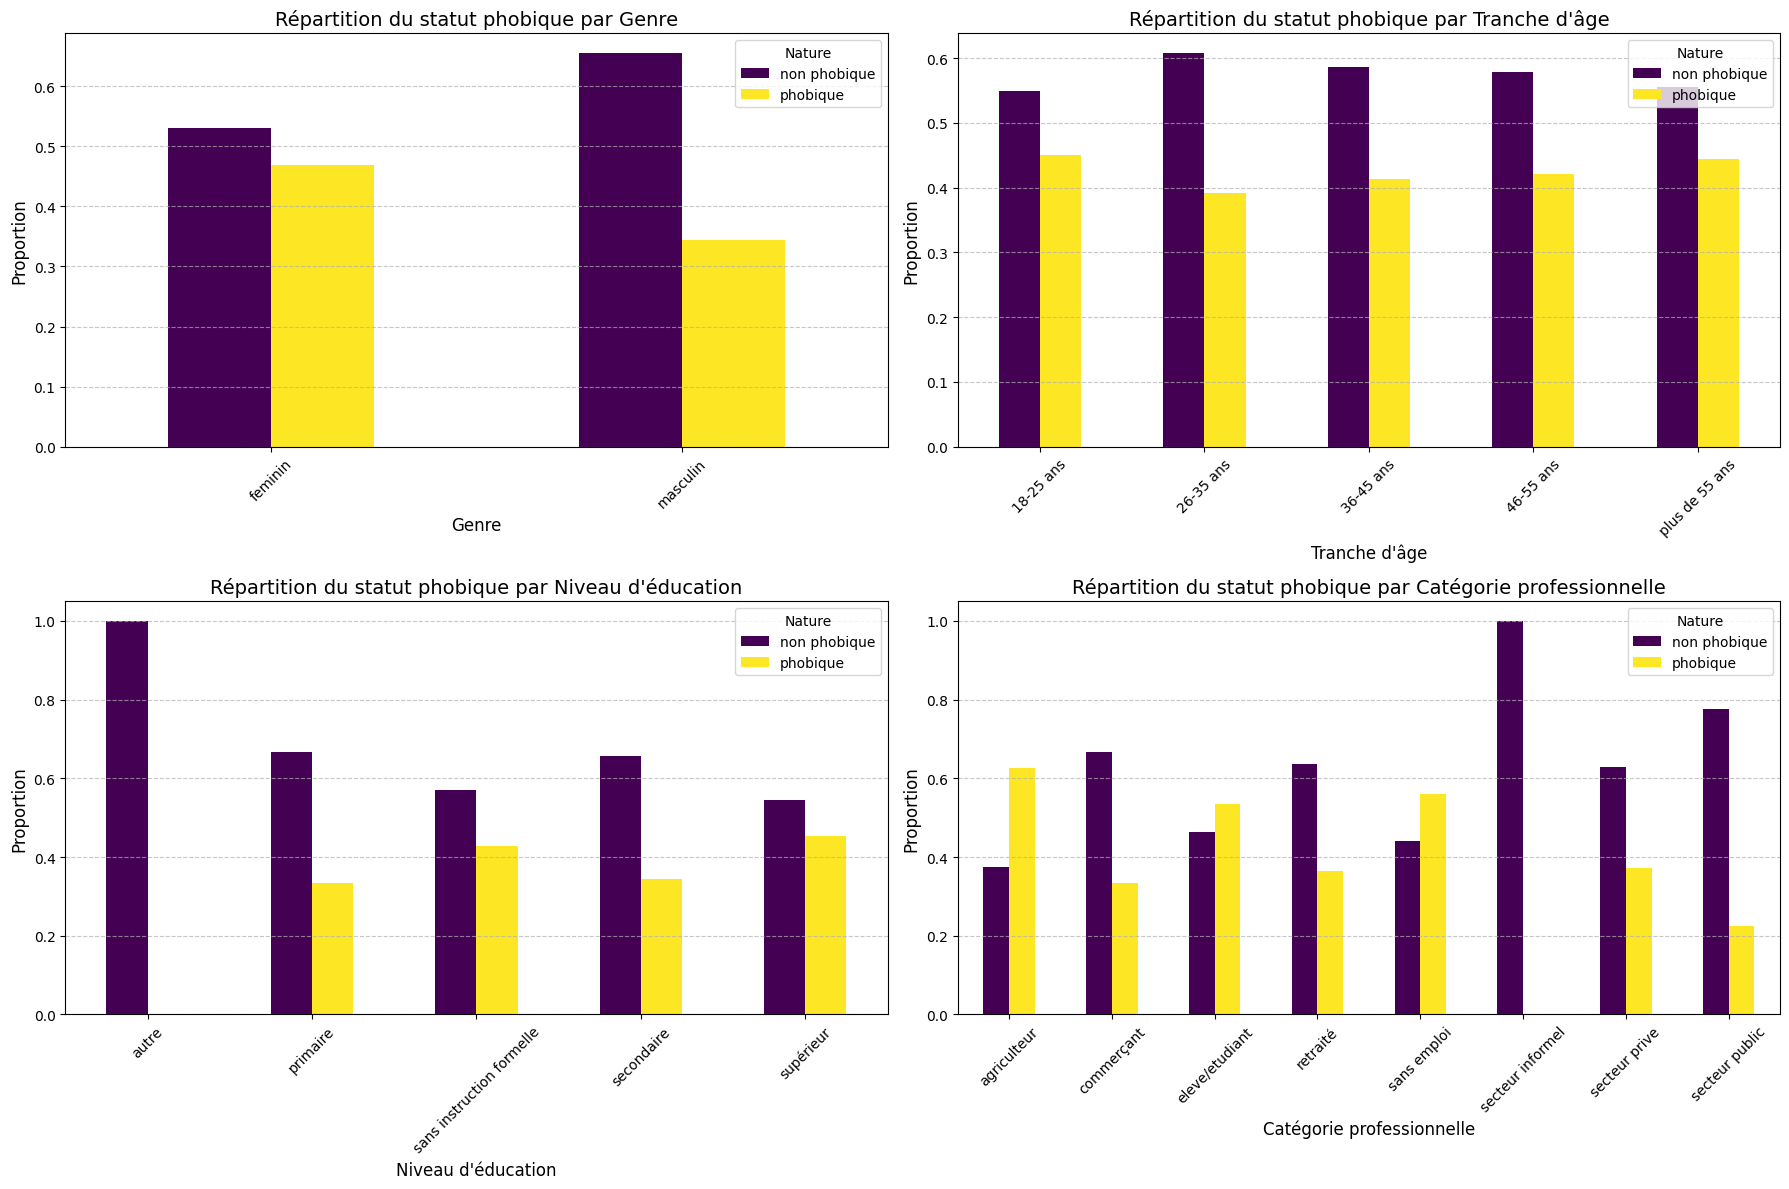

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sociodemographic_vars_for_plot = [
    ('genre', 'Genre'),
    ('age_cat', 'Tranche d\'âge'),
    ('niv_educ', 'Niveau d\'éducation'),
    ('prof', 'Catégorie professionnelle')
]

# Create a figure and a 2x2 grid of subplots
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(18, 12))
axes = axes.flatten() # Flatten the 2x2 array of axes for easy iteration

for i, (var_name, var_label) in enumerate(sociodemographic_vars_for_plot):
    ax = axes[i]

    # Calculate counts of 'nature' within each category of the variable
    ct = pd.crosstab(df[var_name], df['nature'])

    # Calculate percentages within each category of the variable
    ct_pct = ct.div(ct.sum(1).astype(float), axis=0)

    # Plotting
    ct_pct.plot(kind='bar', stacked=False, ax=ax, cmap='viridis')

    ax.set_title(f'Répartition du statut phobique par {var_label}', fontsize=14)
    ax.set_xlabel(var_label, fontsize=12)
    ax.set_ylabel('Proportion', fontsize=12)
    ax.tick_params(axis='x', rotation=45)
    ax.legend(title='Nature', fontsize=10)
    ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

#####**Répartition du statut phobique selon habitudes d'hygiènes buccodentaires**

In [ ]:
hygiene_vars_for_description = [
    ('prem_visite',           'Premiere visite'),
    ('conn_dent_avt', 'Connaissance du dentiste'),
    ('motif',                  'Motif de consultation'),
    ('duree_bross',                      'Duree du brossage'),
    ('dentif_fluor',       'Dentifrice fluoré'),
    ('auto_med',             'Automedication'),
    ('tradi_peur','Recours tradipraticien'),
    ('exp_neg',        'Experience affectante')
]

for var, label in hygiene_vars_for_description:
    if var in df.columns:
        afficher_descriptif_nature(df, var, label)


=== Premiere visite ===
  Modalite                                 Phobiques      Non phob.      Total
  ---------------------------------------------------------------------------
  non                                   94 (81.0%)  133 (81.6%)  227 (81.4%)
  oui                                   22 (19.0%)   30 (18.4%)   52 (18.6%)

=== Connaissance du dentiste ===
  Modalite                                 Phobiques      Non phob.      Total
  ---------------------------------------------------------------------------
  non                                    9 ( 7.8%)   17 (10.4%)   26 ( 9.3%)
  oui                                  107 (92.2%)  146 (89.6%)  253 (90.7%)

=== Motif de consultation ===
  Modalite                                 Phobiques      Non phob.      Total
  ---------------------------------------------------------------------------
  consultation de contrôle               3 ( 2.6%)   10 ( 6.1%)   13 ( 4.7%)
  douleur bucco-dentaire                53 (45.7%)   8

L'analyse descriptive des habitudes de consultation et des comportements liés à la santé bucco-dentaire met en évidence plusieurs différences entre les patients phobiques et non phobiques.

Concernant la première consultation dentaire, la grande majorité des participants, quel que soit leur statut phobique, n'en étaient pas à leur première visite, avec des proportions très proches dans les deux groupes (environ 81 %). La proportion de patients consultant pour la première fois demeure ainsi comparable entre phobiques et non-phobiques.

De même, la connaissance préalable du chirurgien-dentiste avant la consultation est largement répandue dans les deux groupes, concernant environ neuf patients sur dix. Les différences observées entre phobiques et non-phobiques restent minimes.

S'agissant du motif de consultation, la douleur bucco-dentaire constitue la principale raison de consultation, tant chez les patients phobiques (45,7 %) que chez les non-phobiques (52,8 %). Toutefois, les patients phobiques consultent relativement plus fréquemment pour une gêne bucco-dentaire (20,7 % contre 14,1 %), tandis que les non-phobiques sont proportionnellement plus nombreux à consulter pour des motifs esthétiques (15,3 % contre une proportion inférieure chez les phobiques).

L'analyse des habitudes d'hygiène bucco-dentaire révèle des différences notables en matière de durée du brossage. Les patients phobiques sont davantage représentés parmi ceux déclarant se brosser les dents pendant plus de deux minutes (37,9 % contre 18,4 %). En revanche, la proportion de patients se brossant les dents pendant exactement deux minutes est plus élevée chez les non-phobiques (31,9 % contre 15,5 %). Dans les deux groupes, le brossage de moins de deux minutes demeure toutefois la modalité la plus fréquente.

Concernant l'utilisation d'un dentifrice fluoré, près de la moitié des participants ignorent si leur dentifrice contient du fluor. Parmi ceux qui le savent, les non-phobiques déclarent plus fréquemment utiliser un dentifrice fluoré (28,2 % contre 21,6 %), tandis que les phobiques sont proportionnellement plus nombreux à ne pas en utiliser.

Le recours à l'automédication apparaît fréquent dans les deux groupes, mais légèrement plus élevé chez les patients phobiques (66,4 % contre 60,1 %).

En revanche, le recours à un tradipraticien par peur reste marginal et comparable entre les deux groupes, avec une proportion avoisinant 10 à 12 %.

##**PREVALENCE DE LA PEUR DU CHIRURGIEN DENTISTE DANS LA POPULATION ETUDIEE**

In [ ]:
ordre_niveaux = [ # Définit l'ordre souhaité des niveaux d'anxiété
    'Sans anxiete',
    'Anxiete moderee',
    'Anxiete elevee',
    'Phobie severe'
]
das_c = df['niveau_anxiete'].value_counts().reindex(ordre_niveaux, fill_value=0) # Compte les occurrences de chaque niveau d'anxiété et les réindexe
das_pct = (das_c / len(df) * 100).round(1) # Calcule les pourcentages pour chaque niveau

tab5 = pd.DataFrame({ # Crée un DataFrame pour le Tableau V
    'Niveau anxiete': ordre_niveaux,
    'n': das_c.values,
    '%': das_pct.values
})
print('=== TABLEAU V - Niveaux d anxiete dentaire ===') # Affiche un titre pour le tableau
print(tab5.to_string(index=False)) # Affiche le Tableau V sans l'index
cliniq = (df['score_total'] >= 13).sum() # Calcule le nombre de cas d'anxiété clinique (DAS >= 13)
print(f'\nAnxiete clinique (DAS >= 13) : n={cliniq} ({cliniq/279*100:.1f}%)') # Affiche le nombre et le pourcentage d'anxiété clinique
print(f'Score DAS moyen : {df["score_total"].mean():.2f} +/- {df["score_total"].std():.2f}') # Affiche le score DAS moyen et son écart-type
print(f'Mediane DAS     : {df["score_total"].median():.0f}') # Affiche la médiane du score DAS

=== TABLEAU V - Niveaux d anxiete dentaire ===
 Niveau anxiete   n    %
   Sans anxiete  63 22.6
Anxiete moderee 100 35.8
 Anxiete elevee  89 31.9
  Phobie severe  27  9.7

Anxiete clinique (DAS >= 13) : n=116 (41.6%)
Score DAS moyen : 11.12 +/- 3.25
Mediane DAS     : 12


##**DESCRIPTION COMPARATIVE DES POPULATIONS PHOBIQUES (TESTS STATITISTIQUES)**

###**Répartition du statut phobique selon les caractéristiques sociodémographiques**

In [ ]:
from scipy.stats import chi2_contingency, fisher_exact, mannwhitneyu # Importe les fonctions statistiques nécessaires

def test_bivariate(df, var, groupe='nature'): # Définit une fonction pour effectuer des tests bivariés
    ct = pd.crosstab(df[var].dropna(), df.loc[df[var].notna(), groupe]) # Crée un tableau de contingence entre la variable et le groupe 'nature'
    chi2, p_chi2, dof, expected = chi2_contingency(ct) # Effectue le test du Chi-2
    if ct.shape == (2, 2): # Si le tableau de contingence est 2x2, effectue aussi le test exact de Fisher
        _, p = fisher_exact(ct) # Récupère la p-value du test de Fisher
        test_name = 'Fisher' # Nom du test
    else: # Sinon, utilise le test du Chi-2
        test_name = 'Chi2' # Nom du test
        p = p_chi2 # p-value du Chi-2
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns')) # Détermine le niveau de signification
    return ct, test_name, round(p, 4), sig # Retourne le tableau de contingence, le nom du test, la p-value et le niveau de signification

def afficher_croise(df, var, label): # Définit une fonction pour afficher les résultats croisés
    ct, test, p, sig = test_bivariate(df, var) # Appelle la fonction test_bivariate
    phob = df[df['nature']=='phobique'] # Filtre le DataFrame pour les phobiques
    nphob = df[df['nature']=='non phobique'] # Filtre le DataFrame pour les non-phobiques
    print(f'\n=== {label} | {test} | p={p} {sig} ===') # Affiche le titre de la section avec le nom du test et la p-value
    print(f'  {"Modalite":<35} {"Phobiques":>14} {"Non phob.":>14} {"Total":>10}') # Affiche les en-têtes des colonnes
    print('  ' + '-'*75) # Affiche une ligne de séparation
    for mod in df[var].dropna().unique(): # Parcourt chaque modalité unique de la variable
        np_ = (phob[var]==mod).sum() # Nombre de phobiques pour la modalité
        nn_ = (nphob[var]==mod).sum() # Nombre de non-phobiques pour la modalité
        nt  = np_ + nn_ # Nombre total pour la modalité
        pp  = np_/len(phob)*100 if len(phob)>0 else 0 # Pourcentage de phobiques pour la modalité
        pn  = nn_/len(nphob)*100 if len(nphob)>0 else 0 # Pourcentage de non-phobiques pour la modalité
        pt  = nt/len(df)*100 # Pourcentage total pour la modalité
        print(f'  {str(mod):<35} {np_:>4} ({pp:4.1f}%) {nn_:>4} ({pn:4.1f}%) {nt:>4} ({pt:4.1f}%)') # Affiche les résultats pour chaque modalité
    return p, sig # Retourne la p-value et le niveau de signification

print('Fonctions statistiques definies') # Affiche un message de confirmation

Fonctions statistiques definies


In [ ]:
# Genre
afficher_croise(df, 'genre', 'Genre') # Appelle la fonction pour afficher les résultats croisés pour le genre

# Tranche age
afficher_croise(df, 'age_cat', 'Tranche age') # Appelle la fonction pour afficher les résultats croisés pour la tranche d'âge

# Mann-Whitney age continu
ages_p  = df[df['nature']=='phobique']['age'] # Ages des phobiques
ages_np = df[df['nature']=='non phobique']['age'] # Ages des non-phobiques
stat_mw, p_mw = mannwhitneyu(ages_p, ages_np, alternative='two-sided') # Effectue le test de Mann-Whitney U
print(f'\nAge continu - Mann-Whitney : p={p_mw:.4f} {"*" if p_mw<0.05 else "ns"}') # Affiche la p-value du test de Mann-Whitney
print(f'  Phobiques     : {ages_p.mean():.1f} +/- {ages_p.std():.1f}, mediane={ages_p.median():.0f}') # Affiche la moyenne, l'écart-type et la médiane de l'âge pour les phobiques
print(f'  Non phobiques : {ages_np.mean():.1f} +/- {ages_np.std():.1f}, mediane={ages_np.median():.0f}') # Affiche la moyenne, l'écart-type et la médiane de l'âge pour les non-phobiques

# Education
afficher_croise(df, 'niv_educ', 'Niveau education') # Appelle la fonction pour afficher les résultats croisés pour l'éducation

# Profession
afficher_croise(df, 'prof', 'Categorie professionnelle') # Appelle la fonction pour afficher les résultats croisés pour la profession


=== Genre | Fisher | p=0.0492 * ===
  Modalite                                 Phobiques      Non phob.      Total
  ---------------------------------------------------------------------------
  feminin                               75 (64.7%)   85 (52.1%)  160 (57.3%)
  masculin                              41 (35.3%)   78 (47.9%)  119 (42.7%)

=== Tranche age | Chi2 | p=0.9498 ns ===
  Modalite                                 Phobiques      Non phob.      Total
  ---------------------------------------------------------------------------
  26-35 ans                             49 (42.2%)   76 (46.6%)  125 (44.8%)
  46-55 ans                              8 ( 6.9%)   11 ( 6.7%)   19 ( 6.8%)
  18-25 ans                             32 (27.6%)   39 (23.9%)   71 (25.4%)
  36-45 ans                             19 (16.4%)   27 (16.6%)   46 (16.5%)
  plus de 55 ans                         8 ( 6.9%)   10 ( 6.1%)   18 ( 6.5%)

Age continu - Mann-Whitney : p=0.3591 ns
  Phobiques     : 32.8 +/-

(np.float64(0.0048), '**')

L'analyse bivariée des caractéristiques sociodémographiques a mis en évidence plusieurs résultats importants concernant les facteurs associés à la phobie dentaire.

Le genre apparaît significativement associé au statut phobique, comme l'indique le test exact de Fisher (*p* = 0,0492). Cette association traduit une surreprésentation des femmes parmi les patients phobiques, suggérant que le sexe féminin pourrait constituer un facteur associé à une plus grande prévalence de la phobie dentaire.

En revanche, aucune association statistiquement significative n'a été observée entre la tranche d'âge et le statut phobique (test du Chi-deux, *p* = 0,9498). La répartition des différentes catégories d'âge est comparable entre les patients phobiques et non-phobiques.

Cette absence d'association est confirmée lorsque l'âge est analysé comme variable continue. Le test de Mann-Whitney n'a pas mis en évidence de différence significative entre les âges médians des deux groupes (*p* = 0,3591). Bien que l'âge moyen des patients phobiques soit légèrement inférieur à celui des non-phobiques, cet écart ne présente pas de signification statistique.

Par ailleurs, le niveau d'instruction n'est pas significativement associé à la phobie dentaire (test du Chi-deux, *p* = 0,2248). Les différences observées dans la distribution des niveaux d'études entre les deux groupes demeurent compatibles avec les fluctuations aléatoires.

En revanche, la catégorie socioprofessionnelle est fortement associée au statut phobique (test du Chi-deux, *p* = 0,0048). Les élèves et étudiants, ainsi que les personnes sans emploi, sont proportionnellement plus nombreux parmi les patients phobiques. À l'inverse, les travailleurs du secteur public et les commerçants sont davantage représentés parmi les non-phobiques.

En somme, dans notre population d'étude, le genre et la catégorie socioprofessionnelle apparaissent comme des facteurs significativement associés à la phobie dentaire, contrairement à l'âge et au niveau d'instruction.


###**Répartition du statut phobique selon les habitudes d’hygiènes buccodentaires et des soins**

In [ ]:
variables_for_tab4 = [ # Liste des variables pour le Tableau IV (noms renommés)
    ('prem_visite',           'Premiere visite'),
    ('conn_dent_avt', 'Connaissance du dentiste'),
    ('motif',                  'Motif de consultation'),
    ('duree_bross',                      'Duree du brossage'),
    ('dentif_fluor',       'Dentifrice floure'),
    ('auto_med',             'Automedication'),
    ('tradi_peur','Recours tradipraticien'),
    ('exp_neg',        'Experience affectante')
]
for col, label in variables_for_tab4: # Parcourt chaque variable et son étiquette
    if col in df.columns: # Vérifie si la colonne existe dans le DataFrame
        afficher_croise(df, col, label) # Appelle la fonction pour afficher les résultats croisés


=== Premiere visite | Fisher | p=1.0 ns ===
  Modalite                                 Phobiques      Non phob.      Total
  ---------------------------------------------------------------------------
  oui                                   22 (19.0%)   30 (18.4%)   52 (18.6%)
  non                                   94 (81.0%)  133 (81.6%)  227 (81.4%)

=== Connaissance du dentiste | Fisher | p=0.5336 ns ===
  Modalite                                 Phobiques      Non phob.      Total
  ---------------------------------------------------------------------------
  oui                                  107 (92.2%)  146 (89.6%)  253 (90.7%)
  non                                    9 ( 7.8%)   17 (10.4%)   26 ( 9.3%)

=== Motif de consultation | Chi2 | p=0.1772 ns ===
  Modalite                                 Phobiques      Non phob.      Total
  ---------------------------------------------------------------------------
  motif esthétique                      16 (13.8%)   25 (15.3%)   4

L'analyse bivariée a mis en évidence des associations statistiquement significatives entre certaines variables comportementales et le statut phobique.

En ce qui concerne la durée du brossage, le test du Chi-deux a révélé une association hautement significative avec la phobie dentaire (p = 0,0002). Ce résultat indique que la répartition des durées de brossage diffère significativement entre les patients phobiques et non-phobiques. Plus précisément, les patients phobiques sont proportionnellement plus nombreux à déclarer un brossage supérieur à deux minutes, tandis que les non-phobiques sont davantage représentés parmi ceux rapportant une durée de brossage d'exactement deux minutes.

Par ailleurs, l'existence d'une expérience dentaire négative antérieure est également significativement associée au statut phobique, comme l'atteste le test exact de Fisher (p = 0,0088). Les patients présentant une phobie dentaire rapportent plus fréquemment avoir vécu une expérience négative lors d'une consultation ou d'un soin dentaire antérieur, comparativement aux patients non phobiques.

En revanche, aucune association statistiquement significative n'a été observée entre le statut phobique et les autres variables étudiées, notamment la première visite chez le dentiste, la connaissance préalable du chirurgien-dentiste, le motif de consultation, l'utilisation d'un dentifrice fluoré, le recours à l'automédication ou encore le recours à un tradipraticien (p > 0,05). Les différences observées entre les groupes pour ces variables peuvent donc être attribuées aux fluctuations aléatoires de l'échantillonnage.

Ainsi, dans notre population d'étude, seules la durée du brossage et l'antécédent d'une expérience dentaire négative apparaissent significativement associées à la phobie dentaire.

###**Exportation des tableaux croisés**

Cette cellule exporte les tableaux de contingence générés par les analyses bivariées vers un fichier Excel. Chaque variable sociodémographique ou liée aux habitudes d'hygiène/soins aura son propre onglet dans le fichier.

In [ ]:
# Liste de toutes les variables pour lesquelles des tests bivariés ont été effectués
sociodemographic_vars = ['genre', 'age_cat', 'niv_educ', 'prof']
hygiene_vars = [item[0] for item in variables_for_tab4]
all_bivariate_vars = sociodemographic_vars + hygiene_vars

# Exportation des tableaux de contingence vers un fichier Excel
with pd.ExcelWriter('tableaux_bivaries.xlsx') as writer:
    for var in all_bivariate_vars:
        if var in df.columns: # S'assurer que la colonne existe
            ct, _, _, _ = test_bivariate(df, var)
            # Utiliser le nom de la variable comme nom de feuille
            ct.to_excel(writer, sheet_name=f'{var}_vs_nature')

print("Les tableaux de contingence ont été exportés vers 'tableaux_bivaries.xlsx'.")

Les tableaux de contingence ont été exportés vers 'tableaux_bivaries.xlsx'.


In [ ]:
import pandas as pd

# Liste des variables sociodémographiques
sociodemographic_vars = ['genre', 'age_cat', 'niv_educ', 'prof']

# Variables d'hygiène
hygiene_vars = [item[0] for item in variables_for_tab4]

# Liste complète
all_bivariate_vars = sociodemographic_vars + hygiene_vars

# Exportation
output_file = 'tableaux_bivaries.xlsx'

with pd.ExcelWriter(output_file, engine='openpyxl') as writer:
    for var in all_bivariate_vars:
        if var in df.columns:
            try:
                ct, _, _, _ = test_bivariate(df, var)
                ct.to_excel(writer, sheet_name=var[:31])  # Excel limite à 31 caractères
                print(f"Tableau exporté : {var}")
            except Exception as e:
                print(f"Erreur avec la variable '{var}' : {e}")
        else:
            print(f"Variable absente du DataFrame : {var}")

print(f"\nLes tableaux de contingence ont été exportés dans '{output_file}'.")

Tableau exporté : genre
Tableau exporté : age_cat
Tableau exporté : niv_educ
Tableau exporté : prof
Tableau exporté : prem_visite
Tableau exporté : conn_dent_avt
Tableau exporté : motif
Tableau exporté : duree_bross
Tableau exporté : dentif_fluor
Tableau exporté : auto_med
Tableau exporté : tradi_peur
Tableau exporté : exp_neg

Les tableaux de contingence ont été exportés dans 'tableaux_bivaries.xlsx'.


###**Régression logistique multivariée**

In [ ]:
df_reg = df.copy() # Crée une copie du DataFrame pour la régression
df_reg['phobie_bin'] = (df_reg['score_total'] >= 13).astype(int) # Crée une variable binaire pour la phobie (1 si DAS >= 13, 0 sinon)

df_reg['sexe_fem']              = (df_reg['genre'].str.lower()=='feminin').astype(int) # Crée une variable binaire pour le sexe féminin
df_reg['exp_affectante']        = (df_reg['exp_neg'].str.lower()=='oui').astype(int) # Crée une variable binaire pour l'expérience affectante
df_reg['brossage_moins2']       = (df_reg['duree_bross'].str.lower()=='moins de 2mn').astype(int) # Crée une variable binaire pour le brossage de moins de 2 minutes
df_reg['brossage_plus2']        = (df_reg['duree_bross'].str.lower()=='plus de 2mn').astype(int) # Crée une variable binaire pour le brossage de plus de 2 minutes
df_reg['prof_etud_eleve']       = df_reg['prof'].isin(['eleve/etudiant']).astype(int) # Crée une variable binaire pour la profession 'Etudiant/Eleve'
df_reg['prof_prive']            = df_reg['prof'].isin(['secteur prive']).astype(int) # Crée une variable binaire pour la profession 'Secteur privé'
# df_reg['prof_informel']         = df_reg['prof'].isin(['secteur informel']).astype(int) # Cette variable est retirée en raison de la séparation parfaite
df_reg['motif_incft_prothese']  = df_reg['motif'].str.lower().isin(
                                      ['gêne bucco - dentaire','réhabilitation prothétique']).astype(int) # Crée une variable binaire pour les motifs de consultation 'gêne bucco-dentaire' ou 'réhabilitation prothétique'
df_reg['dent_non_floure']       = (df_reg['dentif_fluor'].str.lower()=='non').astype(int) # Crée une variable binaire pour le dentifrice non fluoré

predictors = [ # Liste des prédicteurs à inclure dans le modèle de régression
    'sexe_fem','exp_affectante',
    'brossage_moins2','brossage_plus2',
    'prof_etud_eleve','prof_prive',
    #'prof_informel', # Retiré du modèle
    'motif_incft_prothese','dent_non_floure'
]
df_m = df_reg[['phobie_bin']+predictors].dropna() # Sélectionne les colonnes pertinentes et supprime les lignes avec des valeurs manquantes

import statsmodels.api as sm
X = sm.add_constant(df_m[predictors]) # Ajoute une constante à la matrice des prédicteurs
y = df_m['phobie_bin'] # Variable dépendante
model = sm.Logit(y, X).fit(disp=0) # Ajuste le modèle de régression logistique

import numpy as np # Importe numpy (déjà importé, mais ajouté ici pour l'autonomie du bloc)
params  = model.params # Récupère les coefficients du modèle
conf    = model.conf_int() # Récupère les intervalles de confiance
OR      = np.exp(params) # Calcule les Odds Ratios (OR)
OR_lo   = np.exp(conf[0]) # Calcule la borne inférieure de l'IC à 95% pour les OR
OR_hi   = np.exp(conf[1]) # Calcule la borne supérieure de l'IC à 95% pour les OR
pvals   = model.pvalues # Récupère les p-values

labels_var = { # Dictionnaire pour les étiquettes plus lisibles des variables
    'sexe_fem':            'Sexe feminin',
    'exp_affectante':      'Experience affectante',
    'brossage_moins2':     'Brossage < 2 min',
    'brossage_plus2':      'Brossage > 2 min',
    'prof_etud_eleve':     'Etudiant / Eleve',
    'prof_prive':          'Secteur prive',
    'prof_informel':       'Informel / Autre',
    'motif_incft_prothese':'Motif inconfort/Prothese',
    'dent_non_floure':     'Dentifrice non floure'
}

res_df = pd.DataFrame({ # Crée un DataFrame pour les résultats de la régression
    'Variable'  : [labels_var.get(v, v) for v in params.index[1:]], # Nom des variables
    'ORa'       : OR.values[1:].round(2), # Odds Ratios ajustés
    'IC 95% inf': OR_lo.values[1:].round(2), # Borne inférieure de l'IC
    'IC 95% sup': OR_hi.values[1:].round(2), # Borne supérieure de l'IC
    'p'         : pvals.values[1:].round(4) # P-values
})
res_df['Sig'] = res_df['p'].apply(lambda p: '***' if p<0.001 else ('**' if p<0.01 else ('*' if p<0.05 else ''))) # Ajoute une colonne pour le niveau de signification

print('=== TABLEAU VI - Regression logistique multivariee ===') # Affiche un titre pour le tableau
print(res_df.to_string(index=False)) # Affiche le DataFrame des résultats sans l'index
print(f'\nPseudo R2 McFadden : {1 - model.llf/model.llnull:.4f}') # Affiche le Pseudo R2 de McFadden
print(f'AIC                : {model.aic:.1f}') # Affiche la valeur de l'AIC
print(f'p global (LR test) : {model.llr_pvalue:.6f}') # Affiche la p-value globale du test de rapport de vraisemblance

=== TABLEAU VI - Regression logistique multivariee ===
                Variable  ORa  IC 95% inf  IC 95% sup      p Sig
            Sexe feminin 1.52        0.90        2.58 0.1198    
   Experience affectante 2.14        1.18        3.86 0.0118   *
        Brossage < 2 min 1.78        0.91        3.47 0.0905    
        Brossage > 2 min 3.16        1.49        6.70 0.0027  **
        Etudiant / Eleve 2.04        1.13        3.67 0.0176   *
           Secteur prive 0.98        0.49        1.97 0.9564    
Motif inconfort/Prothese 1.62        0.93        2.84 0.0908    
   Dentifrice non floure 1.88        1.03        3.42 0.0399   *

Pseudo R2 McFadden : 0.0996
AIC                : 359.1
p global (LR test) : 0.000008


L'analyse de régression logistique multivariée a permis d'identifier plusieurs facteurs indépendamment associés à la phobie dentaire.
L'existence d'une expérience dentaire antérieure négative ou affectante constitue un facteur significatif. Après ajustement sur les autres variables du modèle, les individus ayant rapporté une telle expérience présentent un risque de phobie dentaire significativement plus élevé que ceux n'en ayant pas vécu (OR ajusté = 2,14 ; IC95 % : 1,18–3,86 ; p = 0,0118). Autrement dit, ils ont un peu plus de deux fois plus de chances d'être phobiques.
La durée du brossage apparaît également fortement associée à la phobie dentaire. Les participants déclarant un brossage supérieur à deux minutes présentent une probabilité significativement plus élevée d'être phobiques que ceux appartenant à la catégorie de référence (OR ajusté = 3,16 ; IC95 % : 1,49–6,70 ; p = 0,0027). Cette association suggère un risque multiplié par plus de trois.
Par ailleurs, le statut d'élève ou d'étudiant est associé de manière significative à la phobie dentaire. Comparativement aux autres catégories socioprofessionnelles, les élèves et étudiants présentent environ deux fois plus de risque d'être phobiques (OR ajusté = 2,04 ; IC95 % : 1,13–3,67 ; p = 0,0176).
L'utilisation d'un dentifrice non fluoré constitue également un facteur associé à la phobie dentaire. Les utilisateurs de dentifrice non fluoré présentent une probabilité significativement plus élevée d'être phobiques que ceux utilisant un dentifrice fluoré (OR ajusté = 1,88 ; IC95 % : 1,03–3,42 ; p = 0,0399).
En revanche, aucune association statistiquement significative n'a été mise en évidence pour le sexe féminin (OR ajusté = 1,52 ; p = 0,1198), un brossage inférieur à deux minutes (OR ajusté = 1,78 ; p = 0,0905), l'exercice d'une profession dans le secteur privé (OR ajusté = 0,98 ; p = 0,9564) ou encore les motifs de consultation liés à l'inconfort ou à la prothèse (OR ajusté = 1,62 ; p = 0,0908).
Enfin, les indicateurs globaux attestent de la pertinence du modèle. Le test du rapport de vraisemblance est hautement significatif (p = 0,000008), confirmant que le modèle explique significativement la survenue de la phobie dentaire. Le pseudo-R² de McFadden, égal à 0,0996, indique que le modèle explique environ 10 % de la variabilité observée. Quant au critère d'information d'Akaike (AIC = 359,1), il constitue un indicateur utile pour comparer ce modèle à d'éventuels modèles alternatifs.
Ainsi, l'expérience dentaire négative, un brossage prolongé, le statut d'élève ou d'étudiant, ainsi que l'utilisation d'un dentifrice non fluoré apparaissent comme des déterminants indépendants de la phobie dentaire dans notre population d'étude.

###**Préoccupations & Suggestions des phobiques sévères**

In [ ]:
# Tableau VII - Preoccupations (données issues du document DORA V2)
preoccupations = [ # Liste des préoccupations avec leur effectif et pourcentage
    ('Extraction dentaire',               18, 66.7),
    ('Fatigue de la machoire',            10, 37.0),
    ('Embarras etat de la bouche',        10, 37.0),
    ('Necessite de soins nombreux',       10, 37.0),
    ('Bruit de la fraise',                 9, 33.3),
    ('Cout des soins',                     9, 33.3),
    ('Sensation air froid',                8, 29.6),
    ('Possibilite interrompre le soin',    5, 18.5),
    ('Sensation engourdissement',          4, 14.8),
    ('Sentiment de confinement',           3, 11.1),
    ('Odeurs du cabinet',                  1,  3.7),
    ('Question du consentement',           1,  3.7),
]
tab7 = pd.DataFrame(preoccupations, columns=['Preoccupation','n','%']) # Crée un DataFrame à partir des données
print('=== TABLEAU VII - Preoccupations des phobiques severes (n=27) ===') # Affiche un titre pour le tableau
print(tab7.to_string(index=False)) # Affiche le Tableau VII sans l'index

=== TABLEAU VII - Preoccupations des phobiques severes (n=27) ===
                  Preoccupation  n    %
            Extraction dentaire 18 66.7
         Fatigue de la machoire 10 37.0
     Embarras etat de la bouche 10 37.0
    Necessite de soins nombreux 10 37.0
             Bruit de la fraise  9 33.3
                 Cout des soins  9 33.3
            Sensation air froid  8 29.6
Possibilite interrompre le soin  5 18.5
      Sensation engourdissement  4 14.8
       Sentiment de confinement  3 11.1
              Odeurs du cabinet  1  3.7
       Question du consentement  1  3.7


L'analyse des préoccupations exprimées par les patients présentant une phobie dentaire sévère met en évidence une hiérarchisation claire des sources d'anxiété.

L'extraction dentaire constitue, de loin, la principale source d'inquiétude, étant mentionnée par 66,7 % des patients, soit 18 participants sur 27. Cette forte proportion souligne la place centrale qu'occupe cet acte dans la perception anxiogène des soins dentaires.

Un deuxième groupe de préoccupations, rapportées chacune par 37,0 % des patients (10 sur 27), concerne la fatigue de la mâchoire liée à l'ouverture prolongée de la bouche, l'embarras relatif à l'état de santé bucco-dentaire, ainsi que la perspective de devoir recevoir de nombreux soins.

Parmi les préoccupations d'intensité intermédiaire, le bruit de la fraise et le coût des soins sont cités par 33,3 % des participants (9 sur 27), tandis que la sensation d'air froid est rapportée par 29,6 % d'entre eux (8 sur 27).

D'autres inquiétudes, moins fréquemment exprimées, incluent la possibilité d'interrompre le soin (18,5 % ; 5 sur 27), la sensation d'engourdissement (14,8 % ; 4 sur 27) et le sentiment de confinement (11,1 % ; 3 sur 27).

Enfin, certaines préoccupations apparaissent marginales dans cette population, notamment les odeurs du cabinet dentaire et les questions liées au consentement, chacune n'étant mentionnée que par un seul patient (3,7 %).

En définitive, les patients atteints de phobie dentaire sévère expriment principalement des craintes liées aux procédures invasives, aux contraintes physiques du traitement, à l'image de leur santé bucco-dentaire, ainsi qu'aux dimensions sensorielles et financières des soins. Ces résultats soulignent l'importance d'une prise en charge adaptée, tenant compte de ces différentes sources d'anxiété.

###**Suggestions selon les niveaux d'anxiété**

In [57]:
prefs_cols = [ # Liste des colonnes de préférences et leurs étiquettes
    ('pref_explic', 'Explication etapes'),
    ('pref_deco',    'Decoration apaisante'),
    ('pref_bouchons',       'Bouchons oreilles'),
    ('pref_masque',             'Masque yeux'),
    ('pref_musique',           'Musique douce'),
]

ordre_niv = ['Sans anxiete','Anxiete moderee','Anxiete elevee','Phobie severe'] # Ordre des niveaux d'anxiété

results_prefs = {} # Dictionnaire pour stocker les résultats des préférences par niveau d'anxiété
for col, label in prefs_cols: # Parcourt chaque préférence et son étiquette
    if col in df.columns: # Vérifie si la colonne existe
        pct_niv = df.groupby('niveau_anxiete')[col].apply( # Calcule le pourcentage d'adhésion pour chaque niveau d'anxiété
            lambda x: (x.str.lower()=='oui').mean()*100
        ).reindex(ordre_niv, fill_value=0) # Réindexe pour assurer l'ordre
        results_prefs[label] = pct_niv # Stocke les résultats dans le dictionnaire
        glb = (df[col].str.lower()=='oui').mean()*100 # Calcule le pourcentage global d'adhésion
        print(f'{label} (global: {glb:.1f}%)') # Affiche le pourcentage global
        for niv, pct in pct_niv.items(): # Parcourt les niveaux et les pourcentages
            print(f'  {niv}: {pct:.1f}%') # Affiche le pourcentage pour chaque niveau
        print() # Affiche une ligne vide pour la lisibilité

Explication etapes (global: 84.9%)
  Sans anxiete: 92.1%
  Anxiete moderee: 80.0%
  Anxiete elevee: 83.1%
  Phobie severe: 92.6%

Decoration apaisante (global: 55.6%)
  Sans anxiete: 55.6%
  Anxiete moderee: 49.0%
  Anxiete elevee: 57.3%
  Phobie severe: 74.1%

Bouchons oreilles (global: 50.2%)
  Sans anxiete: 28.6%
  Anxiete moderee: 53.0%
  Anxiete elevee: 55.1%
  Phobie severe: 74.1%

Masque yeux (global: 47.3%)
  Sans anxiete: 38.1%
  Anxiete moderee: 52.0%
  Anxiete elevee: 51.7%
  Phobie severe: 37.0%

Musique douce (global: 44.4%)
  Sans anxiete: 33.3%
  Anxiete moderee: 42.0%
  Anxiete elevee: 53.9%
  Phobie severe: 48.1%



Explication des étapes : Globalement, cette option est privilégiée par 84,9 % des participants. Elle est fortement appréciée quel que soit le niveau d’anxiété, avec des proportions particulièrement élevées chez les personnes sans anxiété (92,1 %) ainsi que chez celles présentant une phobie sévère (92,6 %).
Décoration apaisante : Elle est choisie par 55,6 % des participants au total. On observe une augmentation progressive de cette préférence avec le niveau d’anxiété, passant de 55,6 % chez les sujets sans anxiété à 74,1 % chez ceux présentant une phobie sévère.
Bouchons d’oreilles : Globalement, 50,2 % des participants les privilégient. Leur usage est nettement plus faible chez les personnes sans anxiété (28,6 %), mais augmente progressivement avec le niveau d’anxiété pour atteindre 74,1 % chez les sujets souffrant de phobie sévère.
Masque pour les yeux : Cette option est préférée par 47,3 % des participants. La préférence est plus marquée chez les individus présentant une anxiété modérée (52,0 %) et élevée (51,7 %), mais elle diminue chez les personnes atteintes de phobie sévère (37,0 %) par rapport aux autres groupes anxieux.
Musique douce : Elle est choisie par 44,4 % des participants au total. Une tendance similaire à celle de la décoration apaisante est observée, avec une augmentation progressive de la préférence selon le niveau d’anxiété, passant de 33,3 % chez les personnes sans anxiété à 53,9 % chez celles présentant une anxiété élevée, avant une légère baisse chez les sujets souffrant de phobie sévère (48,1 %).